     Variable       VIF
0       const  2.439334
1       close  1.021088
2        MACD  2.166125
3  MACDandSIG  1.100679
4         RSI  2.109983
5     Percent  1.001335


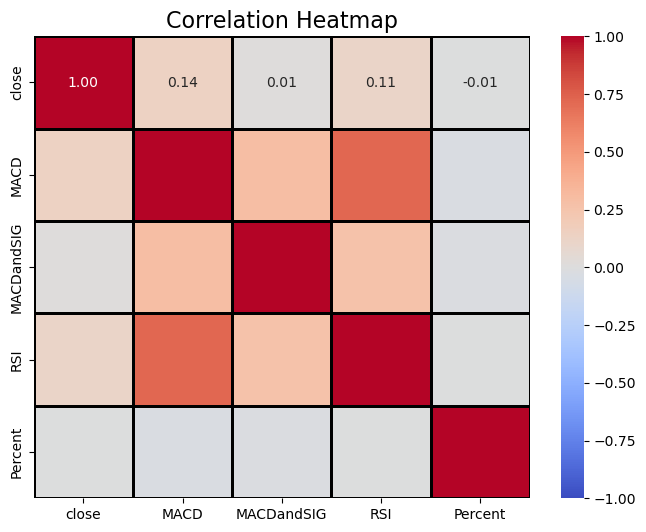

In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns
import matplotlib.pyplot as plt

# Sample dataframe
df = pd.read_csv('data/ADANIPORTS.csv')  # Load your data
df.dropna(inplace=True)
# Let's assume your dataframe is `df` with predictor columns (X1, X2, X3, ...)
X = df[['close','MACD','MACDandSIG','RSI','Percent']]  # Replace with your actual predictors

# Add a constant to the predictor set (for the intercept)
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

df = df[['close','MACD','MACDandSIG','RSI','Percent']]  # Add or modify columns as needed

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt=".2f", linewidths=1, linecolor='black')

# Add a title and labels
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

